In [120]:
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt

In [121]:
loaded_data = datasets.fetch_openml('mnist_784', version=1, as_frame=False)

In [122]:
softmax = lambda Z: (E := np.exp(Z)) / np.sum(E, axis=1, keepdims=True)

In [123]:
sigma = lambda X, W: X @ W

In [124]:
grad = lambda X, S, T: X.T @ (S - T) / S.shape[0]

In [125]:
x_entropy = lambda T, S: -np.sum(T * np.log(S + 1e-8)) / S.shape[0]

In [126]:
forward = lambda X, W: softmax(sigma(X,W))

In [127]:
backward = lambda  X, W, S, T, lr: W - lr * grad(X, S, T)

In [128]:
X, y = loaded_data.data, loaded_data.target
X = X.astype(np.float32)
X /= 255.0

In [129]:
np.sqrt(X[0].shape[0])

np.float64(28.0)

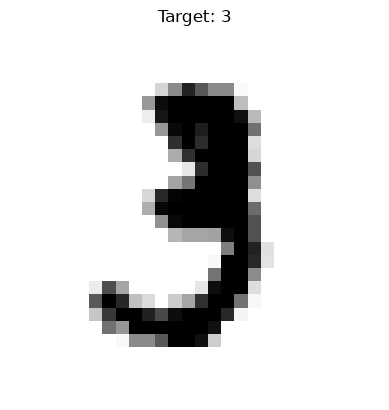

In [130]:
plt.imshow(np.reshape(X[10], (28, 28)), cmap='binary')
plt.axis('off')
plt.title(f"Target: {y[10]}")
plt.show()

In [131]:
num_epoch = 1000
W = np.random.rand(784, 10) * 0.01
T = np.eye(10)[y.astype(int)] # TODO one hot
num_data = X.shape[0]
split = int(num_data * .8)
shuffle = np.random.permutation(num_data)
X_train, T_train = X[shuffle[:split]], T[shuffle[:split]]
X_test, T_test = X[shuffle[split:]], T[shuffle[split:]]
lr = 0.1
snapshot_delay = 100

In [132]:
for epoch in range(num_epoch):
    # forward
    S_train = softmax(sigma(X_train, W))
    if epoch % snapshot_delay == 0: 
        train_loss = x_entropy(T_train, S_train[:split])
        S_test = softmax(sigma(X_test, W))
        test_loss = x_entropy(T_test, S_test)
        print("Epoch: ", epoch)
        print("Train loss: ", train_loss)
        print("Test loss: ", test_loss)
    # backward
    W -= lr * grad(X_train, S_train, T_train)

Epoch:  0
Train loss:  2.2974064269737866
Test loss:  2.2972558680665727
Epoch:  100
Train loss:  0.6076115132708163
Test loss:  0.605910167338687
Epoch:  200
Train loss:  0.48917793049260555
Test loss:  0.4876491416984865
Epoch:  300
Train loss:  0.44068874778159545
Test loss:  0.4396251130862892
Epoch:  400
Train loss:  0.4128550615494027
Test loss:  0.41229257242424616
Epoch:  500
Train loss:  0.3942576739978683
Test loss:  0.39418678538280416
Epoch:  600
Train loss:  0.38070418745402035
Test loss:  0.3811038717750619
Epoch:  700
Train loss:  0.3702553679935934
Test loss:  0.3711021608543279
Epoch:  800
Train loss:  0.3618768752571298
Test loss:  0.36314782197276524
Epoch:  900
Train loss:  0.35496053360509816
Test loss:  0.35663418919823975


In [135]:
X_test_pred = np.argmax(softmax(sigma(X_test, W)), axis=1)

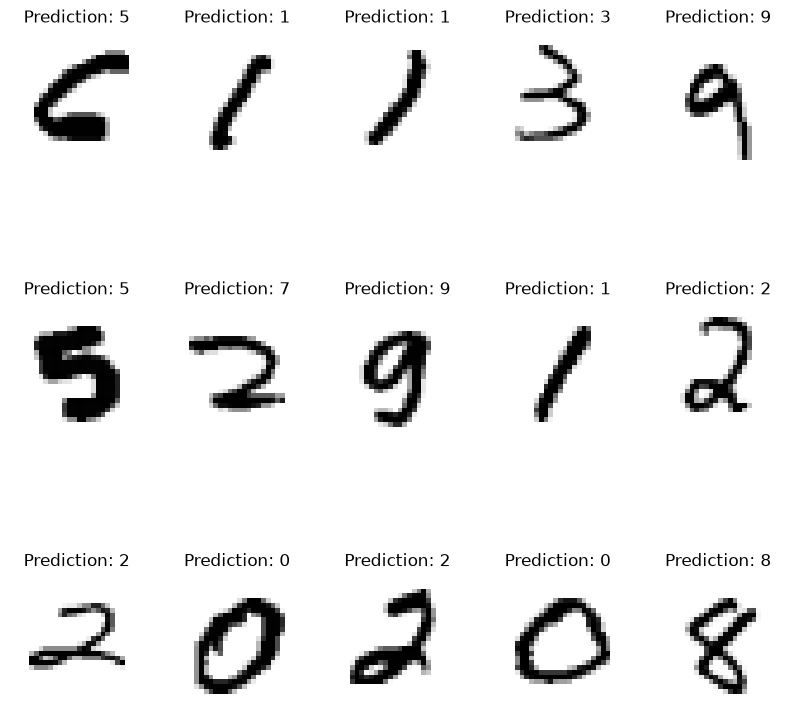

In [136]:


fig, ax = plt.subplots(3,5, figsize=[10, 10])
for i in range(15):
    ax[i//5, i%5].imshow(np.reshape(X_test[i], (28, 28)), cmap='binary')
    ax[i//5, i%5].axis('off')
    ax[i//5, i%5].set_title(f"Prediction: {X_test_pred[i]}")